# 12 — What drives the gain & when to trust it

**What.** Which protein representation is the lever (RIBEX ablation), what predicts reliability (competence boundary), and whether RNA structure adds a non-redundant signal.

**Why.** These set the M2 design choices and the abstention rule.

**Data (Moyon/Marsico lab).** Frozen PARNET `parnet.7m-0.0`, lab binding `binding/{pureclip,narrowpeak_intersect}`, full-223 `encode.filtered.hfds`, ESM/ProtT5/per-residue/STRING, ATtRACT domains. All numbers from committed `mmpartnet_out/*.json`; figures via the reusable `scripts/viz.py` builders, so the same notebook re-plots any teammate's same-schema results. **In-distribution** (all-223 PARNET) unless noted; leave-out PARNET is the decisive follow-up.

## Definitions

**Rep ablation:** per-RBP binding gain for esm/prott5/esm+string (pooled) vs per-residue vs per-residue+string. **Competence:** per-held-RBP gain vs protein-OOD distance $1-\max_h\cos(e_g,e_h)$ and vs binding strength (Spearman). **Structure:** ViennaRNA MFE accessibility added to PARNET features; lever $=\mathrm{auPRC}_{g_r+\text{struct}}-\mathrm{auPRC}_{g_r}$.

In [1]:
import os, sys, json, pathlib
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Markdown, display
_here=pathlib.Path.cwd().resolve()
REPO=next((c for c in (_here,*_here.parents) if (c/'src'/'mmpartnet').is_dir()),_here)
sys.path.insert(0,str(REPO/'scripts')); import viz
OUT=REPO/'mmpartnet_out'; FIGD=REPO/'notebooks'/'demo'/'executed'
def J(n): return json.loads((OUT/n).read_text())
from IPython.display import Image as _Img
def show(fig,name,sup=None):
    if sup: fig.suptitle(sup,fontsize=12.5,fontweight='bold',y=1.02)
    fig.savefig(str(FIGD/name),bbox_inches='tight',dpi=150); plt.close(fig)
    display(_Img(filename=str(FIGD/name)))   # embed the saved PNG inline (backend-independent)
r=J('binding_ribex.json'); c=J('binding_competence.json'); s=J('binding_structure.json')
print('REP gain vs shuffle:', {k: round(r['conds'][k]['gap_der'],3) for k in r['conds']})
print(f"COMPETENCE: Spearman(strength,gain)={c['spearman_strength_gain']:+.2f}  Spearman(OOD,gain)={c['spearman_ood_gain']:+.2f}")
print(f"STRUCTURE: body+struct − body delta {s['delta_mean']:+.4f} CI[{s['delta_ci'][0]:+.4f},{s['delta_ci'][1]:+.4f}] ({s['n_better']}/{s['K']})")

REP gain vs shuffle: {'xattn/esm': 0.076, 'xattn/prott5': 0.078, 'xattn/esm+string': 0.076, 'perres': 0.084, 'perres+string': 0.083}
COMPETENCE: Spearman(strength,gain)=+0.79  Spearman(OOD,gain)=-0.14
STRUCTURE: body+struct − body delta +0.0023 CI[+0.0011,+0.0036] (120/197)


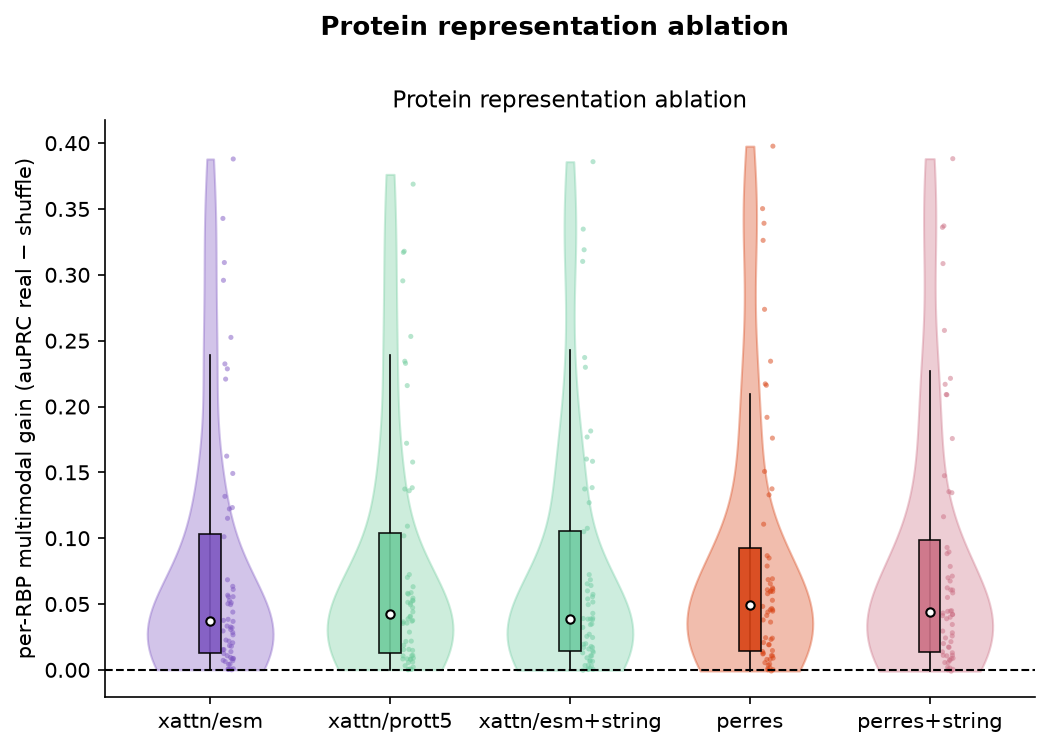

In [2]:
import os, sys, json, pathlib
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Markdown, display
_here=pathlib.Path.cwd().resolve()
REPO=next((c for c in (_here,*_here.parents) if (c/'src'/'mmpartnet').is_dir()),_here)
sys.path.insert(0,str(REPO/'scripts')); import viz
OUT=REPO/'mmpartnet_out'; FIGD=REPO/'notebooks'/'demo'/'executed'
def J(n): return json.loads((OUT/n).read_text())
from IPython.display import Image as _Img
def show(fig,name,sup=None):
    if sup: fig.suptitle(sup,fontsize=12.5,fontweight='bold',y=1.02)
    fig.savefig(str(FIGD/name),bbox_inches='tight',dpi=150); plt.close(fig)
    display(_Img(filename=str(FIGD/name)))   # embed the saved PNG inline (backend-independent)
show(viz.fig_rep(J('binding_ribex.json')),'nb12_rep.png','Protein representation ablation')

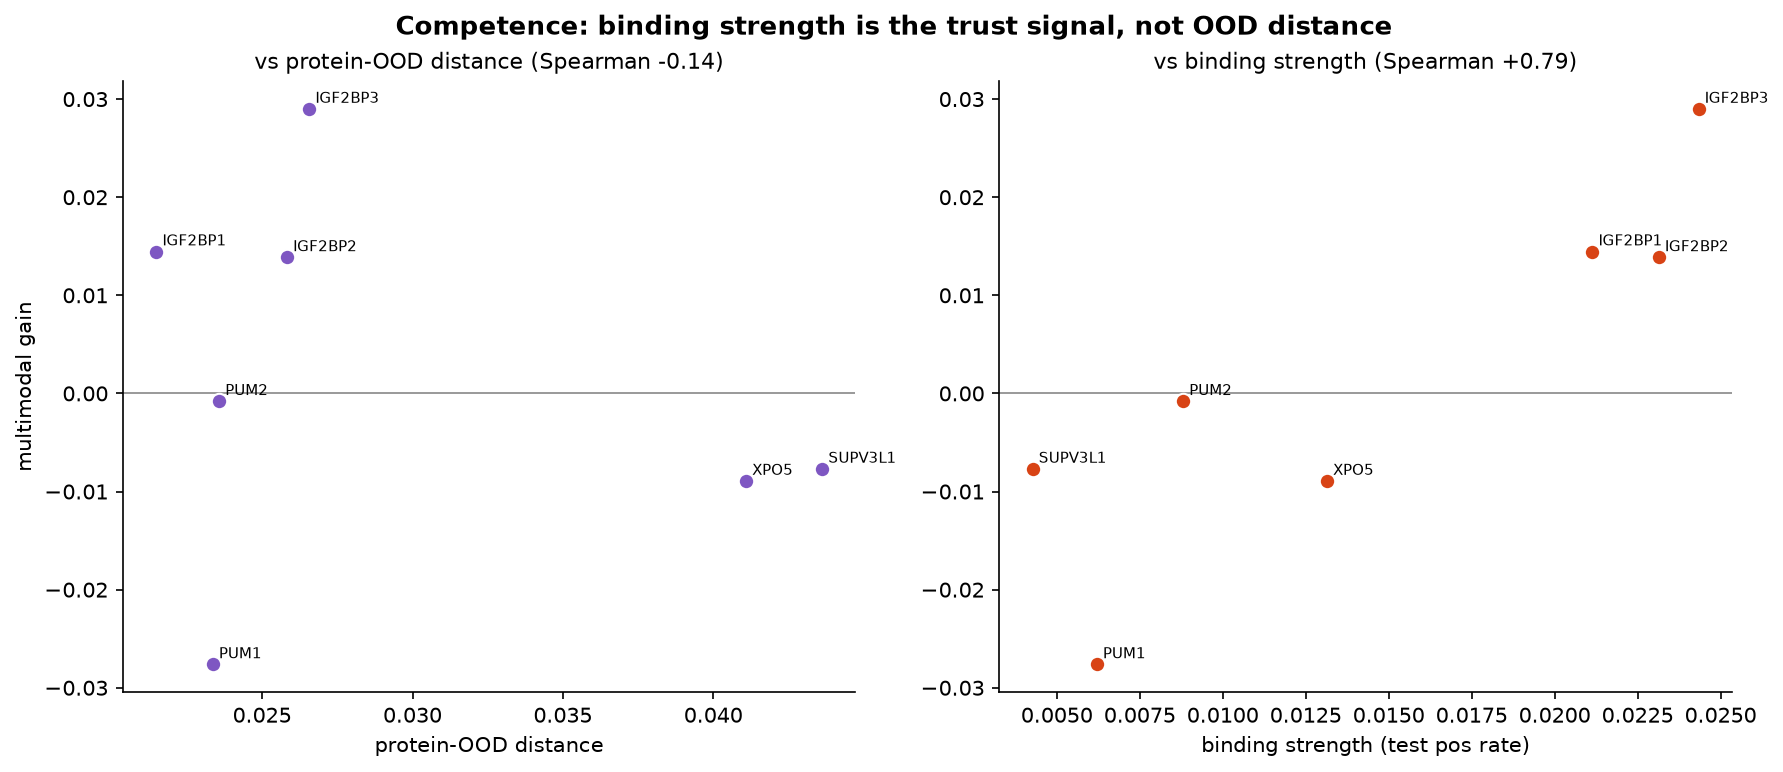

In [3]:
import os, sys, json, pathlib
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Markdown, display
_here=pathlib.Path.cwd().resolve()
REPO=next((c for c in (_here,*_here.parents) if (c/'src'/'mmpartnet').is_dir()),_here)
sys.path.insert(0,str(REPO/'scripts')); import viz
OUT=REPO/'mmpartnet_out'; FIGD=REPO/'notebooks'/'demo'/'executed'
def J(n): return json.loads((OUT/n).read_text())
from IPython.display import Image as _Img
def show(fig,name,sup=None):
    if sup: fig.suptitle(sup,fontsize=12.5,fontweight='bold',y=1.02)
    fig.savefig(str(FIGD/name),bbox_inches='tight',dpi=150); plt.close(fig)
    display(_Img(filename=str(FIGD/name)))   # embed the saved PNG inline (backend-independent)
show(viz.fig_competence(J('binding_competence.json')),'nb12_competence.png','Competence: binding strength is the trust signal, not OOD distance')

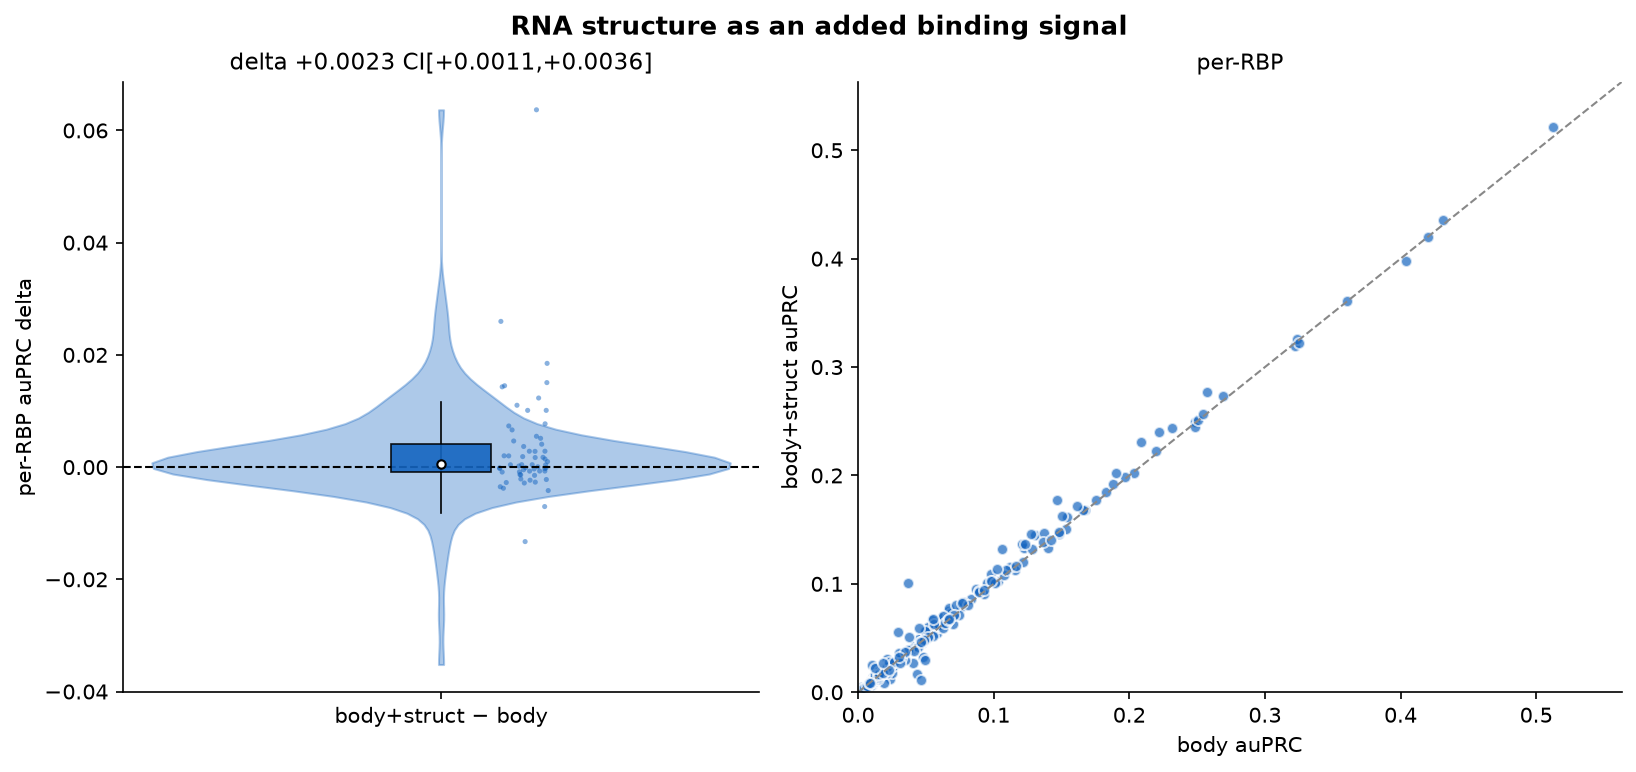

In [4]:
import os, sys, json, pathlib
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Markdown, display
_here=pathlib.Path.cwd().resolve()
REPO=next((c for c in (_here,*_here.parents) if (c/'src'/'mmpartnet').is_dir()),_here)
sys.path.insert(0,str(REPO/'scripts')); import viz
OUT=REPO/'mmpartnet_out'; FIGD=REPO/'notebooks'/'demo'/'executed'
def J(n): return json.loads((OUT/n).read_text())
from IPython.display import Image as _Img
def show(fig,name,sup=None):
    if sup: fig.suptitle(sup,fontsize=12.5,fontweight='bold',y=1.02)
    fig.savefig(str(FIGD/name),bbox_inches='tight',dpi=150); plt.close(fig)
    display(_Img(filename=str(FIGD/name)))   # embed the saved PNG inline (backend-independent)
show(viz.fig_structure(J('binding_structure.json')),'nb12_structure.png','RNA structure as an added binding signal')

In [5]:
import os, sys, json, pathlib
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Markdown, display
_here=pathlib.Path.cwd().resolve()
REPO=next((c for c in (_here,*_here.parents) if (c/'src'/'mmpartnet').is_dir()),_here)
sys.path.insert(0,str(REPO/'scripts')); import viz
OUT=REPO/'mmpartnet_out'; FIGD=REPO/'notebooks'/'demo'/'executed'
def J(n): return json.loads((OUT/n).read_text())
from IPython.display import Image as _Img
def show(fig,name,sup=None):
    if sup: fig.suptitle(sup,fontsize=12.5,fontweight='bold',y=1.02)
    fig.savefig(str(FIGD/name),bbox_inches='tight',dpi=150); plt.close(fig)
    display(_Img(filename=str(FIGD/name)))   # embed the saved PNG inline (backend-independent)
r=J('binding_ribex.json'); c=J('binding_competence.json'); s=J('binding_structure.json'); C=r['conds']
display(Markdown(f'''**Result.** **Per-residue structure is the rep lever** (perres {C['perres']['gap_der']:+.3f} > pooled ESM {C['xattn/esm']['gap_der']:+.3f}); ProtT5≈ESM; STRING/PPI is not robust (esm+string {C['xattn/esm+string']['gap_der']:+.3f}≈esm). **Trust signal = binding strength** (Spearman {c['spearman_strength_gain']:+.2f}), not OOD distance ({c['spearman_ood_gain']:+.2f}). **RNA structure** adds a small but significant lever ({s['delta_mean']:+.4f}, CI excludes 0).'''))

**Result.** **Per-residue structure is the rep lever** (perres +0.084 > pooled ESM +0.076); ProtT5≈ESM; STRING/PPI is not robust (esm+string +0.076≈esm). **Trust signal = binding strength** (Spearman +0.79), not OOD distance (-0.14). **RNA structure** adds a small but significant lever (+0.0023, CI excludes 0).

## Conclusion

Use per-residue protein; gate the abstention on binding strength; RNA accessibility is a modest extra RNA-side signal. ProtT5/ESM interchangeable; STRING not a reliable lever here.

Claude-assisted; methods per Horlacher 2023 (RBPNet) + TFBindFormer/CORAL (cross-attention).